In [1]:
print("Hello world")

Hello world


In [5]:
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

model="openai/gpt-oss-20b"

llm=ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model=model
)

llm.invoke("What is Groq?")

AIMessage(content='**Groq** is a U.S.-based startup that builds a next‑generation AI‑accelerator chip and the software stack that runs on it.  The company was founded in 2018 by a team of former Google engineers (including the original creators of Google’s TPU) and is headquartered in Palo Alto, California.  \n\n---\n\n## 1. What the company does\n\n| Aspect | Details |\n|--------|---------|\n| **Core product** | **Groq Tensor Streaming Processor (TSP)** – a custom ASIC (application‑specific integrated circuit) designed specifically for high‑throughput, low‑latency machine‑learning inference and training. |\n| **Target workloads** | 1‑D and 2‑D convolutions, matrix multiplications, attention mechanisms, and other linear‑algebra kernels that dominate modern deep‑learning models. |\n| **Key differentiators** | * Streaming‑centric architecture: data flows in a one‑way stream from memory to compute units, eliminating costly memory‑to‑memory copies.<br>* Fixed‑point & floating‑point support

In [8]:
from tavily import TavilyClient
import os
from dotenv import load_dotenv
load_dotenv()

tavily_api_key=os.getenv("TAVILY_API_KEY")

print(tavily_api_key)


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


In [27]:
from typing import Literal
from langchain_core.tools import tool

tavily_client=TavilyClient(api_key=tavily_api_key)

@tool
def web_search(query: str, retries: int=5, topic:Literal["general","sports","news"]="general"):
    '''Search the information and give result'''

    return tavily_client.search(query=query, retries=retries, topic=topic)


In [16]:
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model

model=init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="groq"
)
    
    
model




ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E99DAA2210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E99DAA2B10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

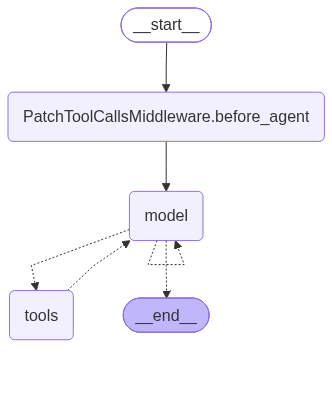

In [28]:
deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a research agent"
)
deepagent

In [29]:
result=deepagent.invoke(
    {"messages":{
        "role": "user",
        "content":"What is deepagent?"
    }}
)
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='f43cd5fc-ce9b-4d63-af38-8c14b2e21e73'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is deepagent?" Likely they refer to "DeepAgent", maybe a software or concept. We need to answer. Could be a research agent? The instructions: act as research agent. So we should search. Use web_search.', 'tool_calls': [{'id': 'fc_7827d0cf-2285-425f-a181-74ff177cddea', 'function': {'arguments': '{"query":"deepagent","retries":5,"topic":"general"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 1967, 'total_tokens': 2054, 'completion_time': 0.090014619, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.118432439, 'prompt_tokens_details': None, 'queue_time': 0.394352193, 'total_time': 0.208447058}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c1

In [30]:
result["messages"][-1].content

'**DeepAgent – a next‑generation AI agent architecture**\n\n| Feature | What it means | Why it matters |\n|---------|---------------|----------------|\n| **End‑to‑end reasoning** | The agent runs a *single* stream of thought that includes planning, tool discovery, execution, and observation. | It avoids the rigid “think‑act‑observe” loops that many simple agents use, giving the model a global view of the task and the freedom to decide *when* and *how* to act. |\n| **Dynamic tool discovery** | The agent can *discover* and *invent* new tools on‑the‑fly, rather than relying on a pre‑defined toolbox. | It can adapt to new domains, learn custom functions, and expand its capabilities without human re‑programming. |\n| **Built‑in planning** | The agent explicitly creates a plan (often as a series of sub‑tasks or a tree), tracks progress, and can back‑track or re‑plan. | Enables long‑running, multi‑step tasks (e.g., research, software development, project management) that would otherwise exhau

In [2]:
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from langchain.chat_models import init_chat_model
model=init_chat_model(
    "openai/gpt-oss-20b",
    model_provider="groq"
)

agent=create_deep_agent(
    model=model,
    backend=StateBackend()
)


In [4]:
result=agent.invoke({

    "messages":[{
        "role":"user",
        "content":(
            "Create a file at /notes/todo.txt with exactly this content:\n- Buy groceries\n- Call Alice\n- Finish project\
                Then tell me youve done it"
        )
    }]
})

In [5]:
result["messages"][-1].content

'✅ The file `/notes/todo.txt` has been created with the requested content.'

In [6]:
result

{'messages': [HumanMessage(content='Create a file at /notes/todo.txt with exactly this content:\n- Buy groceries\n- Call Alice\n- Finish project                Then tell me youve done it', additional_kwargs={}, response_metadata={}, id='9f8c41ca-fd9a-48cf-93ba-af52d6dfb33c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants us to create a file at /notes/todo.txt with the specified content. Then inform them that it has been done. The content includes two lines: "- Buy groceries" and "- Call Alice" and "- Finish project". There\'s also a trailing spaces after "project"? The user typed "Finish project                Then tell me youve done it". Actually the user wrote: "Create a file at /notes/todo.txt with exactly this content:\n- Buy groceries\n- Call Alice\n- Finish project                Then tell me youve done it"\n\nSo the content is:\n\n- Buy groceries\n- Call Alice\n- Finish project\n\nBut the user wrote "Finish project                Then tell me yo

In [7]:
from deepagents.backends import FilesystemBackend

backend=FilesystemBackend(
    root_dir="."
)

agent2=create_deep_agent(
    model=model,
    backend=backend
)
result=agent2.invoke({

    "messages":[{
        "role":"user",
        "content":(
            "Create a file at /notes/todo.txt with exactly this content:\n- Buy groceries\n- Call Alice\n- Finish project\
                Then tell me youve done it"
        )
    }]
})